# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [2]:
# Install required packages (if not available on server, uncomment the lines below)
'''
!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib
'''
!pip3 install getdist


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a} 
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [ ]:
# constants to see if the functions work
h_test = 0.73
Om_test = 0.315
Ol_test = 0.6817


# Hubble rate
def Hubble(z, h, Om, Ol):
    Ok = 1 - Om - Ol            # easier to define Ok inside the function than giving another argument
    a = 1/(1+z)
    H = h * 100 * np.sqrt(Ol + Om * a**-3 + Ok * a**-2)
    return H 

The values of the constants are taken from https://ned.ipac.caltech.edu/level5/March04/Lahav/Lahav1_4.html (retrieved 25.02.2026) and https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies. (retrieved 25.02.2026)

Text(0.5, 1.0, 'Hubble rate as function of redshift z')

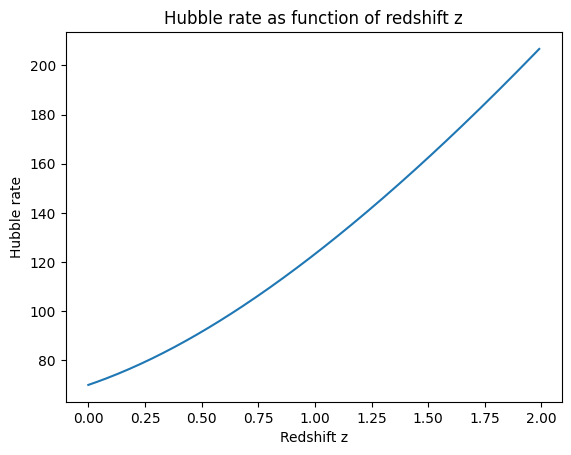

In [141]:
%matplotlib inline

# make arrays with data for the plot
z_values = []
hubble_data = []
for i in range(0, 200):
    z = i * 0.01            # for redshift values in a range between 0 and 2
    H_d = Hubble(z, h_test, Om_test, Ol_test)
    z_values.append(z)
    hubble_data.append(H_d)

# plot
plt.plot(z_values, hubble_data)
plt.xlabel("Redshift z")
plt.ylabel("Hubble rate")
plt.title("Hubble rate as function of redshift z")



As we can see from the graph the Hubble rate is repending on the redshift z in an almost linear function for these small values of z. Also for bigger maxial z-values, the function has a higher curvature in the beginning and is getting more and more linear the higher z is.

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [ ]:
c = 2.998 * 10**5   # speed of light

def D(z, h, Om, Ol):        # definition of the integral that is needed for the luminosity distance formula
    integral_value, error = integrate.quad(lambda z: 1/Hubble(z, h, Om, Ol), 0, z)       # a small explanation of the .quad function is below
    d = h * 100 * integral_value
    return d

print(D(1, h_test, Om_test, Ol_test)) # to check if the funciton works

def theor_luminosity_distance(z, h, Om, Ol, D):     # definition of the formula for the theoretical luminosity distance
    Ok = 1 - Om - Ol
    Ho = h * 100
    if Ok > 0:
        dl = c/Ho * (1 + z) * (1/np.sqrt(Ok) * np.sinh(np.sqrt(Ok) * D(z, h, Om, Ol)))
    elif Ok == 0:
        dl = c/Ho * (1 + z) * (D(z, h, Om, Ol))
    else:
        dl = c/Ho * (1 + z) * (1/np.sqrt(-Ok) * np.sinh(np.sqrt(-Ok) * D(z, h, Om, Ol)))
    dl_pc = dl * 10**6          # to have the result in pc and not Mpc
    return dl_pc # in pc


0.771427066427811


Explanation of parts of the code above:

The scipy.integrate.quad-function calculates the integral of the given function (the first argument given) in the range defined (the in this case last two arguments given, 0 and z). Writing the function in the form "lambda z: 1/Hubble(z, h, Om, Ol)" means that z is the argument, so the variable that is integrated over, and h, Om, and Ol are arguments given for the function as well, but they are constants. The function returns the value of the integral, as well as the absolute error of the result, and can return a dictionary with additional information, a convergence message and further explanations in special cases as well.
Information about the scipy.integrate.quad-function was retrieved from https://docs.scipy.org/doc/scipy/tutorial/integrate.html, https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html, and https://www.codecademy.com/resources/docs/scipy/scipy-integrate/quad (all retrieved on the 02.03.2026).


## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [ ]:
#dataloc = "http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"
dataloc = "/Users/Mara/PRA3024/Week 4/SCPUnion2.1_mu_vs_z.txt" # the location of the datafile needs to be written here!
# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')
display(data[0])

array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

In [8]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

In [9]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

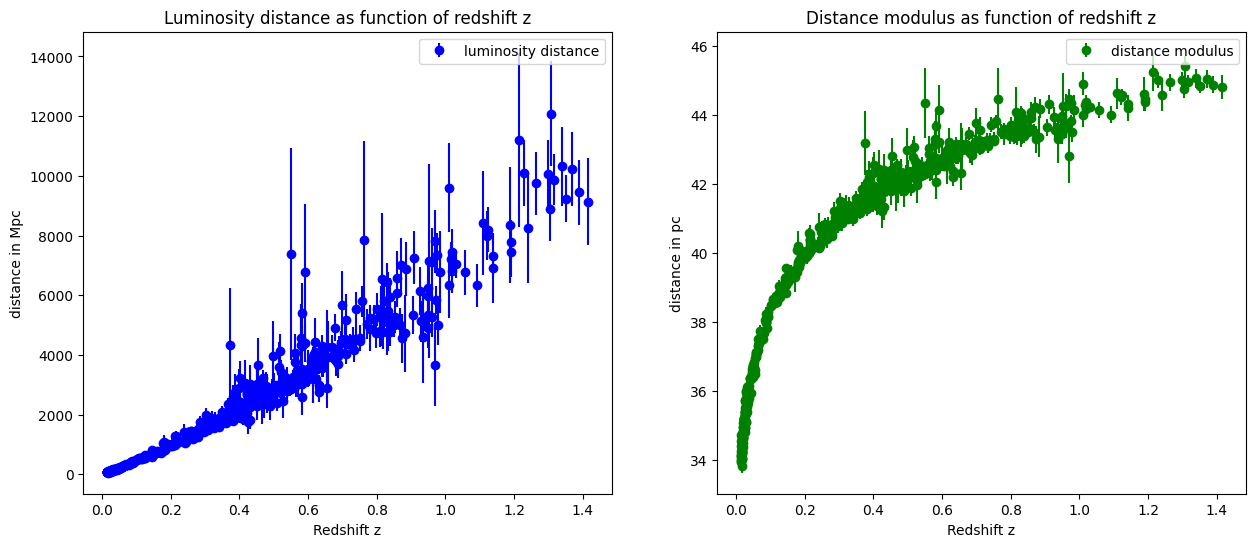

In [ ]:
%matplotlib inline

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # plotting the luminosity distance and the distance modulus in different plots, because they have different orders of magnitude
plt.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt= 'o', color="blue", label="luminosity distance")
plt.xlabel("Redshift z")
plt.ylabel("distance in Mpc")
plt.title("Luminosity distance and error as function of redshift z")
plt.legend()

plt.subplot(1, 2, 2)
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt="o", color="green", label="distance modulus")
plt.xlabel("Redshift z")
plt.ylabel("distance in pc")
plt.title("Distance modulus and error as function of redshift z")
plt.legend()


In these graphs we can see the relationship between the distance modulus and the luminosity distance quite well: the data points of the luminosity distance form a line with increasing slope (as we know from the formula relating the distance modulus and the luminosity distance this slope is actually an exponential function), and the data from the distance modulus, which is in short the logarithm of the luminosity distance, forms a logarithmic-looking curve.

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [ ]:
# function for the theoretical distance modulus
def theor_distance_modulus(z, h, Om, Ol, D):
    mu = 5 * np.log10(theor_luminosity_distance(z, h, Om, Ol, D)/10) # theor_luminosity_distance is a function in pc-units, so mu is also in pc
    return mu # in pc

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

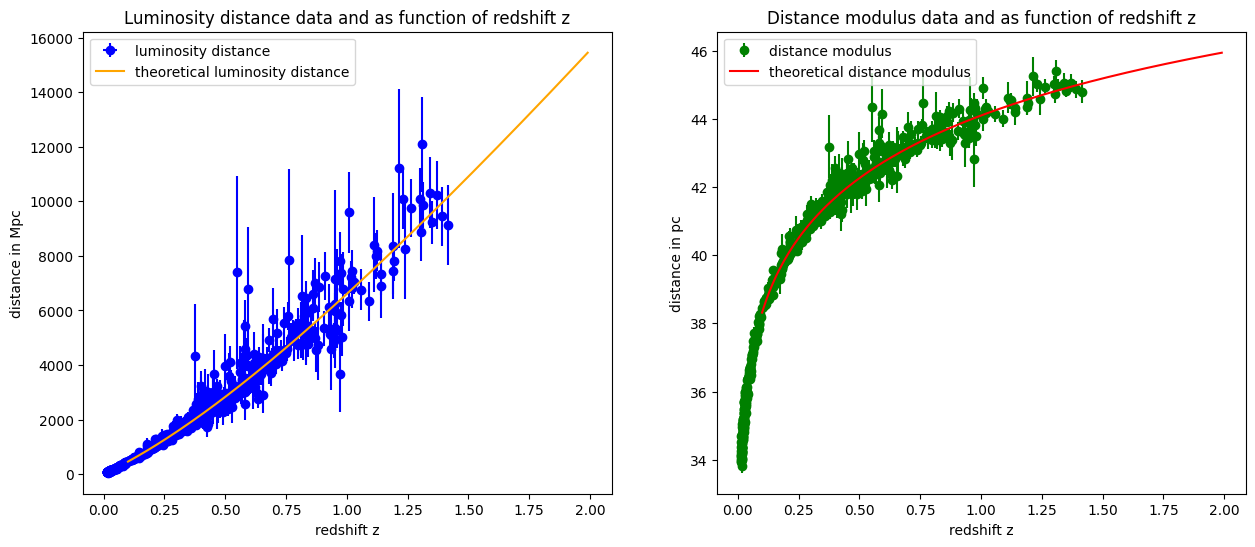

In [57]:
%matplotlib inline

# testconstants
Om_test = 0.3
Ol_test = 0.7
h_test = 0.7

# theor_luminosity_distance-values and theor_distance_modulus-values in arrays to plot them against an array of redshift values (z_val_arr)
z_val_arr = []      # definition of empty arrays to later write step by step the calculated values in
theor_luminosity_distance_arr = []
theor_distance_modulus_arr = []
for i in range(10, 200):        # range 10, 200 to get a redshift range between 0.1 and 2
    z_val = i * 0.01            # calculation of redshift values
    z_val_arr.append(z_val)     # appending array of redshift values
    tld = theor_luminosity_distance(z_val, h_test, Om_test, Ol_test, D)/10**6  # theor_luminosity_distance is in pc -> devide by 10^6 to recieve result in Mpc
    theor_luminosity_distance_arr.append(tld)
    tdm = theor_distance_modulus(z_val, h_test, Om_test, Ol_test, D)    # calculating disdante modulus by function
    theor_distance_modulus_arr.append(tdm)                              # appending array with values


# plot of the theoretical function of luminosity distance together with the data
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)    # again two subplots, now each with the data from the file and the plotted functions
plt.errorbar(zs, luminosity_distance_Mpc, xerr=0, yerr=error_luminosity_distance_Mpc, fmt= 'o', color="blue", label="luminosity distance")
plt.errorbar(z_val_arr, theor_luminosity_distance_arr, color="orange", label="theoretical luminosity distance") 
plt.xlabel("redshift z")
plt.ylabel("distance in Mpc")
plt.title("Luminosity distance data and as function of redshift z")
plt.legend()

# plot of the theoretical function of distance modulus together with the data
plt.subplot(1, 2, 2)
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt="o", color="green", label="distance modulus")
plt.errorbar(z_val_arr, theor_distance_modulus_arr, color="red", label="theoretical distance modulus")
plt.xlabel("redshift z")
plt.ylabel("distance in pc")
plt.title("Distance modulus data and as function of redshift z")
plt.legend()


Also in the functions of the theoretical luminosity distance and distance modulus we can recognize the exponential-like and logarithmic function. As we can see for the theoretical formulas, the luminosity distance is in this case actually not just defined as a simple exponential function but as a hyperbolic function (Omega_k>0 for our test-values of Omega_m and Omega_l).

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [143]:
from random import random
from random import gauss
import sys


def calculate_chi2(theta, D): # definition of the function to calculate chi^2
    h = theta[0]
    Om = theta[1]
    Ol = theta[2]
    chi2=0
    i = 0
    for z in zs:        # iterate through all redshift values in the data
        x = ((theor_distance_modulus(z, h, Om, Ol, D) - distance_modulus[i])**2)/error_distance_modulus[i]**2
        chi2 += x       # summing the results of every single calculation up to the last element of zs
        i += 1          # to iterate through all distance_modulus-values (zs is not necessarily a sorted array, but the arrays of 
                        # distance_modulus and error_distance_modulus depend on zs, so if the for-loop goes through every element of zs
                        # the i-th element of (error_)distance_modulus corresponds to the i-th element of zs, and therefore this loop
                        # uses the correct elements together)
    return chi2


# open the file with the results and write a first line with the names of the variables that are goint to be written into the file to make
# sure we know later which column contains which variable
filename = "MC_Chain_SNIa.txt"
file = open(filename,"w")
file.write("h Omega_m Omega_l chi^2\n")


#  define initial guess/value parameters
h_start = 0.5
Om_start = 0.5
Ol_start = 0.5

 
theta_old = [h_start, Om_start, Ol_start]       # a first theta_old array
chi2_start = calculate_chi2(theta_old, D)       # calculation of the first chi^2
file.write(f"{theta_old[0]} {theta_old[1]} {theta_old[2]} {chi2_start}\n")      # writing the start values into the textfile with the data


print("Progress: ")

start = time.time()     # measuring the time the following piece of code needs to run


i = 0
nr_accepted = 0
nr_total_steps = 0
negative_count = 0
not_accepted_row = 0
while i in range (0, 8000):     # to stop the MCMC after set amount of runs

    chi2_old = calculate_chi2(theta_old, D)  # calculating chi^2 for the current values of theta
    
    # gaussian distribution to take the next step
    theta_prop = []
    g_dist_0 = gauss(theta_old[0], 0.05)        
    g_dist_1 = gauss(theta_old[1], 0.05) 
    g_dist_2 = gauss(theta_old[2], 0.05)

    theta_prop.append(g_dist_0)     # add new values to the new proposed array of theta
    while 0>g_dist_1:
        g_dist_1 = gauss(theta_old[1], 0.05) 
        negative_count += 1         # i just added this count so that i can see in the end if there ever was a negative value encountered
    theta_prop.append(g_dist_1)    
    theta_prop.append(g_dist_2)

    chi2_prop = calculate_chi2(theta_prop, D)   # calculate chi^2 of the new proposed values

    # random number between 0 and 1
    r = random()
    a = np.exp((chi2_old-chi2_prop)/2)      # calculation for comparison and decision if those values should be accepted or not

    # decisions about the acceptance of new values
    if r<a:
        nr_accepted += 1        # count the accepted steps
        file.write(f"{theta_prop[0]} {theta_prop[1]} {theta_prop[2]} {chi2_old}\n") # if the proposed values are accepted, they are written into the text file
        theta_old = theta_prop  # the proposed values become the new old values for the next loop
        not_accepted_row = 0
    elif a<r:
        theta_prop = theta_old          
        not_accepted_row += 1
    
    nr_total_steps += 1     # counting the total number of steps


    if not_accepted_row==750:        # to stopp the function if no values are accepted x times in a row
        break

    i += 1      # to make sure we get to the next round of the while loop

print("last values:", theta_old)
print("negative_count = ", negative_count)
print("not_accepted_row=", not_accepted_row)

print("Done! Acceptance ratio = ", nr_accepted/nr_total_steps)
file.close()

end = time.time()
print('time required: {:.2f} s'.format(end-start))

Progress: 
last values: [0.6965878663805736, 0.7476636482323976, 0.9370878777403211]
negative_count =  0
not_accepted_row= 7
Done! Acceptance ratio =  0.035625
time required: 105.80 s


Comments on the code above besides what is noted in the code:
I got an a RuntimeWarning saying "overflow encountered in exp", which meant the exponential function used to calculate a which then would be compared to the random number r. I tried to solve this by doing things as making the inide of the exponential-function a 128-float using np.float128(), which did not work but gave back the error "AttributeError: module 'numpy' has no attribute 'float128'". Another thing I tried was to import warnings and ignore filterwarnings, however I was not sure if that would actually solve the problem or just stop the warning from being displayed, therefore I did not end up writing this in the end and when I removed both things again to have the same code as I had before, the problem seemed to have magically solved, at least I did not get the RuntimeWarning again (maybe I accidentally changed some small thing that solved it). However if it does show up in you testrun, I wanted to let you know that I tried to solve it, but did not manage to. (Ideas how to solve this problem were taken from https://www.geeksforgeeks.org/python/how-to-fix-runtimewarning-overflow-encountered-in-exp/ (retrieved 02.03.2026))

The negative_count and the not_accepted_row counting if there were negative values in the gaussian distribution determining the new value of Omega_m and the number of not accepted theta-proposed in row are mostly printed to have an idea if negative values actually happen (yes, but not often) and to know if the while-loop was stopped because the number of not accepted theta in a row was higher than the limit given.

Another comment I want to make is, that sometimes the final values drift off very much and do not end up anywhere close to the expected values. I did not find out how to solve this probmlem, I played around with the standard-deviation of the gaussian distribution functions, the number of runs of the while-loop and the number of not-accepted theta-values after which the while-loop should be stopped, however I did not find a combination that always comes close to the expected values. Probably there is a way to get close to the expected values with more certainty, however I did not find it. Some thought processes and results are written below: 
Even if I set the starting value for Omega_m to 0.3 (h_start=0.5 and Ol_start=0.5) and do 8000 runs, I arrive at final values like (0.7, 0.255, 0.7), [0.6965152247116336, 0.155532375048694, 0.5136689837853611], [0.6999497056648448, 0.28163364950783076, 0.7455389991879485], and as you can see, sometimes the final result is not close to the expected result.
If I only accept the step if a>1 and if the start value of Omega_m is 0.3, I get the following results: [0.6997885316051297, 0.27276327186456684, 0.7171595971446659], [0.6977717389509698, 0.23766645611996876, 0.6567552443426571], which is much better for these two tests at least, however if that is only because we set Omega_m at the start that close to the final expected value already, the use of the MCMC is questionable, so I want to try to get results that are accurate starting with values further away from the expected values.
If I only accept the step if a>1 and of the starting values are [0.5, 0.5, 0.5] (h_start, Om_start, Ol_start), I get the following results: [0.7001147682958025, 0.2845151388027909, 0.7298408133655971], [0.7000424023934315, 0.5138326709829923, 0.8404331048870584], the results are quite far from the expected.
(Since for 8000 repetitions the code takes about 1min40s to run, I did not run each verstion many times.)

After implementing an if-loop that stops the while-loop if 100 values in a row did not get accepted, I got the following results (starting values [0.5, 0.5, 0.5], back to a>r and gaussian distribution standard deviations at (0.1, 0.02, 0.02)): [0.6971370886527642, 0.1571077594002717, 0.5378896467279108], [0.6948046267872343, 0.2916017800934577, 0.6293424365807019], [0.6850983943227222, 0.5717092364401044, 0.6424269869868551], [0.6792295034818306, 0.5546028510928805, 0.5939340981322521]. (It seems to happen quite often that 100 values in a row are not getting accepted, all of these runs did not take more than 20s, and some of the results are not close to the accepted ones, so this is not the solution.)

If that if-loop stpos after 500 not accepted values, I get the following results: [0.7018038835236872, 0.5126502933688908, 0.846278838504722] (not stopped), [0.7042528369097278, 0.8809745071052767, 1.042734961763916] (not stopped),
If that if-loop stops after 250 not accepted values: [0.6992243028240832, 0.3849808840552753, 0.7573447604822432], [0.6967221556123554, 0.5510682351854994, 0.820042860916731] (not stopped), [0.7027930752444801, 0.2799117970778409, 0.7357888691641129], most also too far from the expected values.

For all of the versions above, I have used standard-deviations of 0.1, 0.02, 0.02 for the gaussian distributions of h, Om, Ol, in the following the results for standard-deviations of 0.05, 0.05, 0.05 and a break of the while loop after 250 not accepted values: [0.6973932232852076, 0.247960021490552, 0.6086989825195905] (not stopped), [0.699684727281226, 0.7118532349105835, 0.9434441094744996] (stopped)
And without stopping the function at all: [0.7060635524030551, 0.7544729465894967, 1.0408717395216596], [0.6968097710717034, 0.6311310726530802, 0.8479087845267819], all of these results are still not what we want.

Going back to testing different starting values: If tested with 0.7, 0.3, 0.7 (h, Om, Ol): [0.6981257603010578, 0.660714742100484, 0.8811468234936339], 
0.7, 0.3, 0.7 and enabling the break after 250: [0.7020929347405985, 0.4225122408278356, 0.7995162003131543] (stopped), [0.701201604078298, 0.2618714908655748, 0.7078816493771672] (not stopped), [0.6966728143118623, 0.5416012153445156, 0.8417353945643633] (not stopped). These results are surprisingly bad considering that the starting values are already basically the expected values.
0.7, 0.3, 0.7 and enabling the break after 250 and a>1: [0.701322681660967, 0.3300969070167171, 0.7490684296968217] (stopped), [0.6992058076763905, 0.32200325456381507, 0.7422100264165169] (stopped), [0.7004069443736147, 0.3417299475943357, 0.7606208432443636] (stopped), [0.6981414602113415, 0.27135001081181703, 0.6805606136573572] (stopped), [0.6997278313639114, 0.4048686076828451, 0.7762164845712489] (stopped)
0.7, 0.3, 0.7 and enabling the break after 500 and a>1: [0.698257265408997, 0.2594081371620262, 0.6774685691594955] (stopped), [0.7009199183502516, 0.2666274298752129, 0.7179124627590996] (stopped), [0.700553345421679, 0.311185030917656, 0.7415136159172381] (stopped), [0.6997176312537174, 0.3192851529163407, 0.737739129790378] (stopped). This is the first version where I am happy with the results, however it still does not feel like it makes sense to start as values this close to the final expected values.

Even though this was not a parameter we were supposed to play around with, it seems like only accepting a if a>1 instead of a>r where r is random between 0 and 1, helps in recieving the expected results, therefore I am keeping this for the following tests and changing the starting values again to 0.5, 0.5, 0.5 (and keeping the break at 500 not-accepted values in a row): [0.7004546925247646, 0.2754115008370395, 0.7073359569337149] (stopped), [0.6964706366197186, 0.20551501938907452, 0.596116494715534] (stopped), [0.6997027963570521, 0.7177130049838236, 0.9408945398850624] (stopped), [0.6993754267901222, 0.2857958628410961, 0.7297202369384711] (stopped), [0.701205183162946, 0.30194836592738167, 0.7447257335593789] (stopped), [0.7008200448306003, 0.33107572760382875, 0.7529978836315301] (stopped), [0.6993637781789414, 0.22596018947152754, 0.6552516697542751] (stopped), these results are once again not great.

These values are still not always very precise what is expected, however I will see if they get more precise if the while loop is only stopped at 750 not-accepted values:
[0.7006536731142862, 0.6920428092420868, 0.9295968604608699] (stopped), [0.6995126478661851, 0.29627110258606565, 0.7217108445509529] (stopped), [0.7003856581020892, 0.28850384904071896, 0.7311234739219565] (stopped), [0.6990057450142093, 0.2601000068586539, 0.6808232205117989] (stopped), [0.6993220196395912, 0.6954855234744455, 0.9236498661351957] (stopped), [0.699308305016363, 0.29740196189660995, 0.7282183485712913] (stopped)
Increasing to 1000 not-accepted values: [0.6992361418080061, 0.24470307717113884, 0.6755082808867797] (stopped), [0.7014253032930726, 0.4397316537241153, 0.8131277028897934] (stopped), [0.7005825648067534, 0.347464218266462, 0.7687700783956235] (stopped), [0.6998305103456283, 0.2727680198217716, 0.7137995809897395] (stopped), [0.700085938109247, 0.3265494718152774, 0.7495040752854437] (stopped), these results are not too bad I think.

Adn changing back to a>r as was supposed to (keeping starting values of (0.5, 0.5, 0.5) and the break after 1000 not-accepted values): [0.6955712880605375, 0.4348218680203871, 0.7493011273464311] (not stopped), [0.7004746957382714, 1.1928623365342457, 1.2044357792363507] (not stopped), [0.6984468670688697, 0.6427964723887625, 0.907754852417379] (not stopped). Maybe this was bad luck, but these results are so far away from the expected values, that I can not take this as a possible version.
Since this does not constantly keep giving results close to what expected, I am going back to a 750-break for a few tests ([0.7003443744115795, 2.145533316152989, 1.677052277763641] (not stopped), [0.7016353220521615, 0.7300785281038159, 0.9615504916715568] (not stopped), [0.696649800602821, 0.29864732441244496, 0.6914808766797919] (not stopped), still not as good as it shoudl be).

It seems like no matter how much I experiment with the starting values or the standard deviation of the gaussian dinstributions or other things, I can not always get the expected results, so I assume there are mistakes in my code, other parameters I have not considered or other things I missed.

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(202, 4)
Removed no burn in
0.69  <  h  <  0.7  at  68% CL
0.28  <  OmegaM  <  0.7  at  68% CL
0.69  <  OmegaL  <  0.93  at  68% CL
-0.63  <  Omegak  <  0.04  at  68% CL




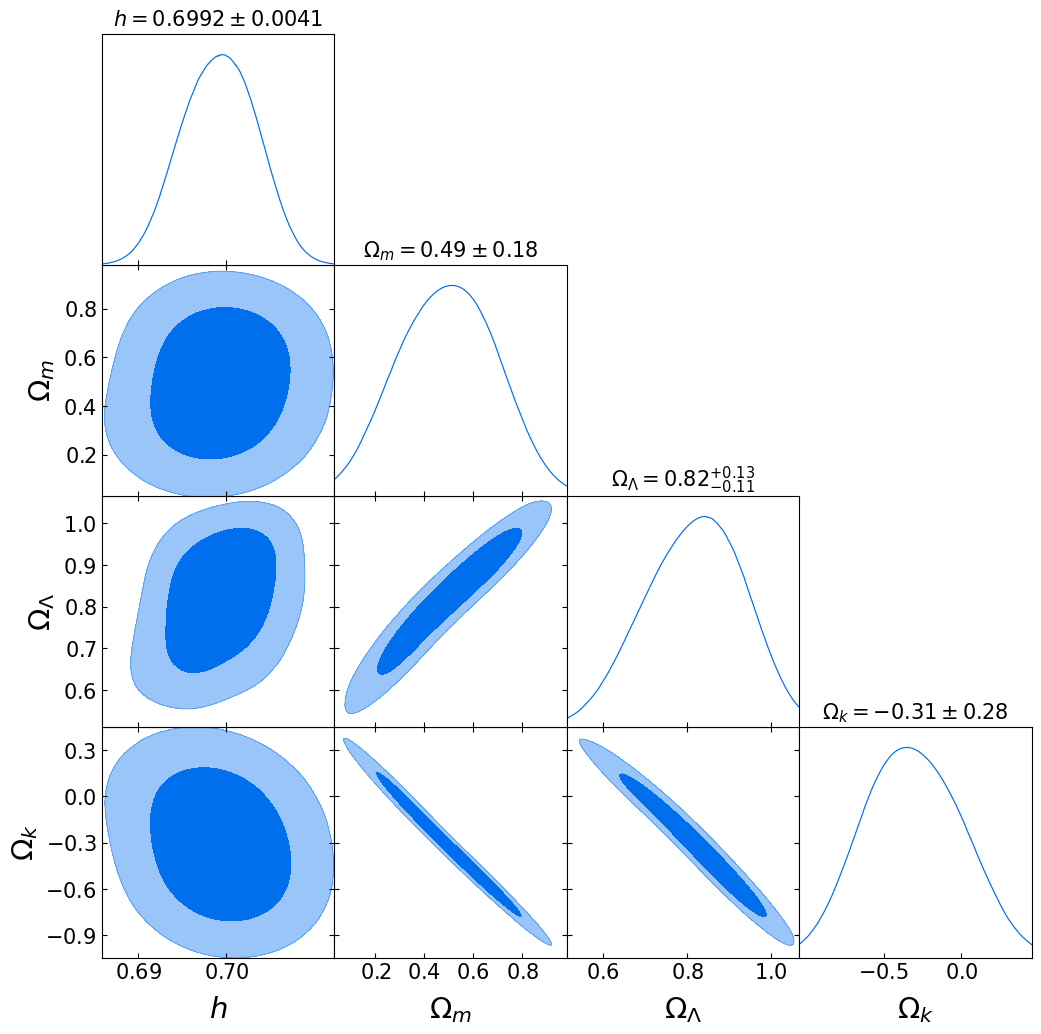

In [144]:
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * nr_accepted)) # remove some burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,0], datafile[:,1], datafile[:,2], datafile[:,3]

# You can easily create new np.arrays that are functions of other np.arrays
Omegak = 1. - OmegaM - OmegaL

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'OmegaM', 'OmegaL', 'Omegak']
my_dim = len(my_names) # The number of variables we're plotting


# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, Omegak], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an "MCSamples" data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          " < ", nam , " < ", round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          " at " , int(100*conf_level),"\b% CL")
print("\n")


#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)

In [204]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



Interestingly for these graphs it sometimes looks like there is not a single extrema (the expected values for h, Omega_l and Omega_m) that can be found by the MCMC, but either the gaussian distributions are centered around another value for them or there are even two extrema in the gaussian distributions.
What I take from this, is that the extrema we are looking for is not a very strong one with values around it that differ much, but rather a four-dimensional surface with very small slopes so that there other extrema can be found as well that are maybe only slightly worse than the other ones. The only value where this MCMC constantly finds a final value around the expected value is h (the circular shapes also suggest a strong enough extrema in h-direction), however for the Omegas based on the rather stretched oval shapes I imagine the extrema in the surface to be not point-like extrema but "valley"-like extrema where it can be difficult for the function to find the absolute extremum between the different values (the graphs not involving h are not always but quite often rather oval than circular-shaped).

##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces. 

0.6965878663805736 0.7476636482323976 0.9370878777403211


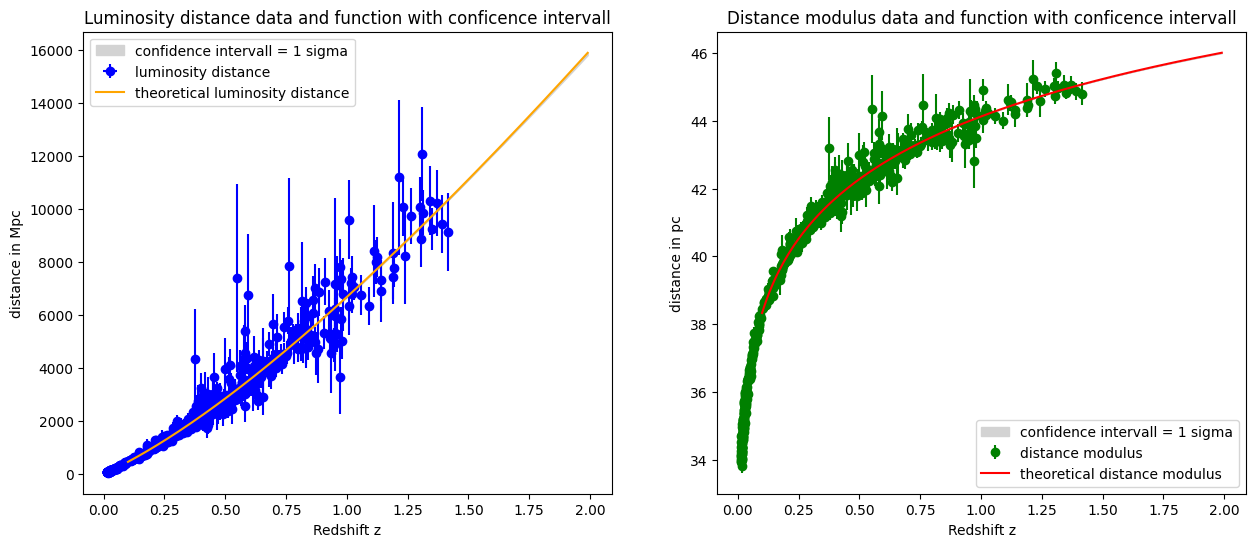

In [ ]:

##Example of how to get the confidence intervals from your MCMC samples
h_min = my_samples.confidence('h',(1.-conf_level)/2.,upper=False)
h_max = my_samples.confidence('h',(1.-conf_level)/2.,upper=True)
Omega_M_min = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=False)
Omega_M_max = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=True)
Omega_L_min = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=False)
Omega_L_max = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=True)


##<-- YOUR CODE GOES HERE!  calculate d_L and mu as a function of z using the best fit parameters from MCMC

# getting the best fit parameters from MCMC
h_best = h[-1]
OM_best = OmegaM[-1]
OL_best = OmegaL[-1]
OK_best = 1 - OM_best - OL_best

# defining empty arrays that then can be appended by the calculated values for every z
d_L_arr = []
mu_arr = []
z_arr = []
d_L_min_arr = []
d_L_max_arr = []
mu_min_arr = []
mu_max_arr = []
for i in range(10, 200): # calculating best, minimum and maximum value of the luminosity distance and distance modulus and appending the arrays by the values
    z = i * 0.01 # calculating a z for each round of the for-loop
    d_L = theor_luminosity_distance(z, h_best, OM_best, OL_best, D)/10**6   # has to be divided by 10^6 again to have result in Mpc and not in pc
    d_L_min = theor_luminosity_distance(z, h_min, Omega_M_min, Omega_L_min, D)/10**6
    d_L_max = theor_luminosity_distance(z, h_max, Omega_M_max, Omega_L_max, D)/10**6
    mu = theor_distance_modulus(z, h_best, OM_best, OL_best, D)
    mu_min = theor_distance_modulus(z, h_min, Omega_M_min, Omega_L_min, D)
    mu_max = theor_distance_modulus(z, h_max, Omega_M_max, Omega_L_max, D)
    d_L_arr.append(d_L)
    d_L_min_arr.append(d_L_min)
    d_L_max_arr.append(d_L_max)
    mu_arr.append(mu)
    mu_min_arr.append(mu_min)
    mu_max_arr.append(mu_max)
    z_arr.append(z)


#print best fit values coming from MCMC
print(h_best, OM_best, OL_best)


# plot your d_L and mu together with the data to compare
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # again a subplot for the luminosity distance in Mpc
plt.errorbar(zs, luminosity_distance_Mpc, xerr=0, yerr=error_luminosity_distance_Mpc, fmt= 'o', color="blue", label="luminosity distance") # data
plt.errorbar(z_arr, d_L_arr, color="orange", label="theoretical luminosity distance") # graph of function
plt.fill_between(z_arr, d_L_min_arr, d_L_max_arr, color="lightgrey", label="confidence intervall = 1 sigma") # confidence intervall (one sigma)
plt.xlabel("Redshift z")
plt.ylabel("distance in Mpc")
plt.title("Luminosity distance data and function with conficence intervall")
plt.legend()

plt.subplot(1, 2, 2) # and a subplot for the distance modulus in pc
plt.errorbar(zs, distance_modulus, yerr=error_distance_modulus, fmt="o", color="green", label="distance modulus") # data
plt.errorbar(z_arr, mu_arr, color="red", label="theoretical distance modulus") # graph of function
plt.fill_between(z_arr, mu_min_arr, mu_max_arr, color="lightgrey", label="confidence intervall = 1 sigma") # confidence intervall (one sigma)
plt.xlabel("Redshift z")
plt.ylabel("distance in pc")
plt.title("Distance modulus data and function with conficence intervall")
plt.legend()




Resource used to plot the confidence intervall of the function: https://www.practicaldatascience.org/notebooks/class_5/week_1/1.2.8_errorbars.html (retrieved 02.03.2026)

The one-sigma confidence intervall is very narrow in both plots, and barely includes any more datapoints than the function itself, and it does not get much wider when using 2-sigma or 3-sigma confidence intervals. 

What we at least can see here is that the functions work with the values we found for h, Omega_m and Omega_l. Even if the values found by the MCMC are not the expected values, the functions still fit the data points quite well. The widths of the confidence intervalls are very small most of the time, but might be slightly wider for a different result from the MCMC.